# Detection of Suspicious Transactions via Anomaly Detection (AML Project)

**Course:** Data Science  
**Author:** Slavena Georgieva
**Date:** April 2026

---

## 1. Introduction

Money laundering is the process of concealing the origins of illegally obtained money.
According to the United Nations, between **800 billion and 2 trillion** are laundered
globally each year — representing 2–5% of global GDP.

Traditional rule-based Anti-Money Laundering (AML) systems flag transactions based on
fixed thresholds (e.g. transactions above $10,000). While simple, these systems produce
high false-positive rates and are easily circumvented by criminals who deliberately
structure transactions to stay below detection thresholds.

This project takes a **statistical and machine learning approach** — using Anomaly Detection
to identify suspicious transactions based on their deviation from normal behaviour,
rather than fixed rules.

### Objectives
- Perform Exploratory Data Analysis (EDA) on two independent AML datasets
- Test a statistical hypothesis about transaction amounts
- Apply and compare three anomaly detection methods: Z-score, IQR, and Isolation Forest

## 2. Research Hypothesis

**Null Hypothesis (H₀):**  
There is no statistically significant difference between the transaction amounts
of normal and suspicious transactions.

**Alternative Hypothesis (H₁):**  
Suspicious transactions have significantly higher amounts compared to normal transactions.

$$H_0: \mu_{suspicious} = \mu_{normal}$$

$$H_1: \mu_{suspicious} > \mu_{normal}$$

This is a **one-tailed test** (right-tailed), since H₁ is directional — we expect
suspicious transactions to be *higher*, not just different.

We use a significance level of **α = 0.05**.

## 3. Data Sources & Description

### Sampling Strategy

Due to file size constraints (SAML-D: ~950MB, IBM HI-Large: ~15GB),
this project works with carefully constructed samples from each dataset.

Initial stratified sampling returned only 2 suspicious transactions from SAML-D,
which is insufficient for statistical analysis. Therefore we apply a new strategy:
**all suspicious transactions are kept** (9,873 total) combined with 5,000 randomly
selected normal transactions.

For IBM HI-Large, the first 500,000 rows contained only 35 laundering transactions.
We therefore combine 5,000 normal transactions with 5,000 laundering transactions
extracted directly from HI-Large_Patterns.txt.

| Dataset | Total rows | Normal | Suspicious | % Suspicious |
|---------|-----------|--------|------------|--------------|
| SAML-D | 14,873 | 5,000 | 9,873 | 66.4% |
| IBM HI-Large | 10,000 | 5,000 | 5,000 | 50.0% |

Full datasets are available on Kaggle (see README).

In [1]:
import pandas as pd
import numpy as np

# ── Load full SAML-D ───────────────────────────────────
saml_full = pd.read_csv('SAML-D.csv')

print(f"Full SAML-D shape: {saml_full.shape}")
print(f"Columns: {saml_full.columns.tolist()}")
print("\nLabel distribution:")
print(saml_full.iloc[:, -1].value_counts())


Full SAML-D shape: (9504852, 12)
Columns: ['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

Label distribution:
Laundering_type
Normal_Small_Fan_Out      3477717
Normal_Fan_Out            2302220
Normal_Fan_In             2104285
Normal_Group               528351
Normal_Cash_Withdrawal     305031
Normal_Cash_Deposits       223801
Normal_Periodical          210526
Normal_Plus_Mutual         155041
Normal_Mutual              125335
Normal_Foward               42031
Normal_single_large         20641
Structuring                  1870
Cash_Withdrawal              1334
Deposit-Send                  945
Smurfing                      932
Layered_Fan_In                656
Layered_Fan_Out               529
Stacked Bipartite             506
Behavioural_Change_1          394
Bipartite                     383
Cycle                         382

In [2]:
# ── Identify label column ──────────────────────────────
label_col = saml_full.columns[-1]  # usually last column

# ── Stratified sample (preserves suspicious ratio) ─────
saml_sample = saml_full.groupby(label_col, group_keys=False).apply(
    lambda x: x.sample(
        n=min(len(x), int(10_000 * len(x) / len(saml_full))),
        random_state=42
    )
).reset_index(drop=True)

print(f"Sample shape: {saml_sample.shape}")
print("\nLabel distribution in sample:")
print(saml_sample[label_col].value_counts())

# ── Save sample ─────────────────────────────────────────
saml_sample.to_csv('saml_sample.csv', index=False)
print("\n✓ Saved: saml_sample.csv")


Sample shape: (9985, 12)

Label distribution in sample:
Laundering_type
Normal_Small_Fan_Out      3658
Normal_Fan_Out            2422
Normal_Fan_In             2213
Normal_Group               555
Normal_Cash_Withdrawal     320
Normal_Cash_Deposits       235
Normal_Periodical          221
Normal_Plus_Mutual         163
Normal_Mutual              131
Normal_Foward               44
Normal_single_large         21
Cash_Withdrawal              1
Structuring                  1
Name: count, dtype: int64

✓ Saved: saml_sample.csv


C:\Users\Славена\AppData\Local\Temp\ipykernel_6260\2182074138.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  saml_sample = saml_full.groupby(label_col, group_keys=False).apply(


In [3]:
# ── Read IBM dataset in chunks (file is huge) ───────────
print("Reading IBM file in chunks... (this may take 1–2 minutes)")

chunks = []
for chunk in pd.read_csv(
    'HI-Large_Trans(1).csv',
    chunksize=100_000,
    dtype={'Account': str, 'Account.1': str},
    low_memory=False
):
    chunks.append(chunk)
    if len(chunks) == 5:  # read first ~500k rows
        break

ibm_full = pd.concat(chunks).reset_index(drop=True)

print(f"Loaded shape: {ibm_full.shape}")
print(f"Columns: {ibm_full.columns.tolist()}")


Reading IBM file in chunks... (this may take 1–2 minutes)
Loaded shape: (500000, 11)
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


In [4]:
# ── Parse HI-Large_Patterns.txt ───────────────────────
with open('HI-Large_Patterns.txt', 'r') as f:
    content = f.read()

rows = []
for line in content.split('\n'):
    line = line.strip()
    if line.startswith('BEGIN') or line.startswith('END') or line == '':
        continue
    parts = line.split(',')
    if len(parts) >= 11:
        rows.append(parts)

patterns_df = pd.DataFrame(rows, columns=[
    'Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
    'Amount Received', 'Receiving Currency', 'Amount Paid',
    'Payment Currency', 'Payment Format', 'Is Laundering'
])
patterns_df['Is Laundering'] = 1

print(f"Suspicious от Patterns: {len(patterns_df)}")

# ── 5000 suspicious + 5000 normal ─────────────────────
suspicious = patterns_df.sample(n=5000, random_state=42)
normal = ibm_full[ibm_full['Is Laundering'] == 0].sample(n=5000, random_state=42)

ibm_final = pd.concat([normal, suspicious]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"IBM final shape: {ibm_final.shape}")
print(f"Distribution:\n{ibm_final['Is Laundering'].value_counts()}")

ibm_final.to_csv('ibm_sample_final.csv', index=False)
print("✓ Saved: ibm_sample_final.csv")

Suspicious от Patterns: 137936
IBM final shape: (10000, 11)
Distribution:
Is Laundering
1    5000
0    5000
Name: count, dtype: int64
✓ Saved: ibm_sample_final.csv


In [5]:
# ── Зареди финалните sample файлове ───────────────────
saml = pd.read_csv('saml_sample_final.csv')
ibm = pd.read_csv('ibm_sample_final.csv')

print("=== SAML-D Sample ===")
print(f"Shape: {saml.shape}")
print(f"Columns: {saml.columns.tolist()}")
print(f"Suspicious: {saml['Is_laundering'].sum():.0f} ({saml['Is_laundering'].mean()*100:.1f}%)")

print("\n=== IBM HI-Large Sample ===")
print(f"Shape: {ibm.shape}")
print(f"Columns: {ibm.columns.tolist()}")
print(f"Suspicious: {ibm['Is Laundering'].sum()} ({ibm['Is Laundering'].mean()*100:.1f}%)")

=== SAML-D Sample ===
Shape: (14873, 12)
Columns: ['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']
Suspicious: 9873 (66.4%)

=== IBM HI-Large Sample ===
Shape: (10000, 11)
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
Suspicious: 5000 (50.0%)


In [6]:
# Вземи всички suspicious + 5000 normal от пълния SAML-D
susp = saml_full[saml_full['Is_laundering'] == 1.0]
normal = saml_full[saml_full['Is_laundering'] == 0.0].sample(n=5000, random_state=42)

saml_final = pd.concat([susp, normal]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Shape: {saml_final.shape}")
print(f"Distribution:\n{saml_final['Is_laundering'].value_counts()}")

saml_final.to_csv('saml_sample_final.csv', index=False)
print("✓ Saved: saml_sample_final.csv")

Shape: (14873, 12)
Distribution:
Is_laundering
1    9873
0    5000
Name: count, dtype: int64
✓ Saved: saml_sample_final.csv


In [9]:
saml = pd.read_csv('saml_sample_final.csv')
ibm = pd.read_csv('ibm_sample_final.csv')

print("=== SAML-D Sample ===")
print(f"Shape: {saml.shape}")
print(f"Suspicious: {saml['Is_laundering'].sum():.0f} ({saml['Is_laundering'].mean()*100:.1f}%)")

print("\n=== IBM HI-Large Sample ===")
print(f"Shape: {ibm.shape}")
print(f"Suspicious: {ibm['Is Laundering'].sum()} ({ibm['Is Laundering'].mean()*100:.1f}%)")

=== SAML-D Sample ===
Shape: (14873, 12)
Suspicious: 9873 (66.4%)

=== IBM HI-Large Sample ===
Shape: (10000, 11)
Suspicious: 5000 (50.0%)


## 4. Exploratory Data Analysis (EDA)

Before applying statistical tests or anomaly detection, we explore the structure 
and distributions of both datasets.

Key questions:
- How are transaction amounts distributed for normal vs. suspicious transactions?
- How imbalanced are the classes?
- Are there visible patterns in payment type or location?

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# ── Описателна статистика SAML-D ───────────────────────
print("=== SAML-D: Amount statistics by class ===")
print(saml.groupby('Is_laundering')['Amount'].describe().round(2))

print("\n=== IBM: Amount statistics by class ===")
print(ibm.groupby('Is Laundering')['Amount Paid'].describe().round(2))

=== SAML-D: Amount statistics by class ===
                count      mean        std    min      25%      50%       75%  \
Is_laundering                                                                   
0              5000.0   8472.14   15424.87  12.92  2190.64  6153.60  10553.88   
1              9873.0  40587.67  419181.13  15.82  2723.79  5322.79   9789.67   

                       max  
Is_laundering               
0                456191.48  
1              12618498.40  

=== IBM: Amount statistics by class ===
                count         mean           std    min      25%       50%  \
Is Laundering                                                                
0              5000.0    826871.31  1.312848e+07   0.01    19.98   2132.36   
1              5000.0  50114799.34  2.057239e+09  15.58  5604.69  11824.53   

                    75%           max  
Is Laundering                          
0              25440.30  5.764778e+08  
1              18920.54  1.300515e+11  


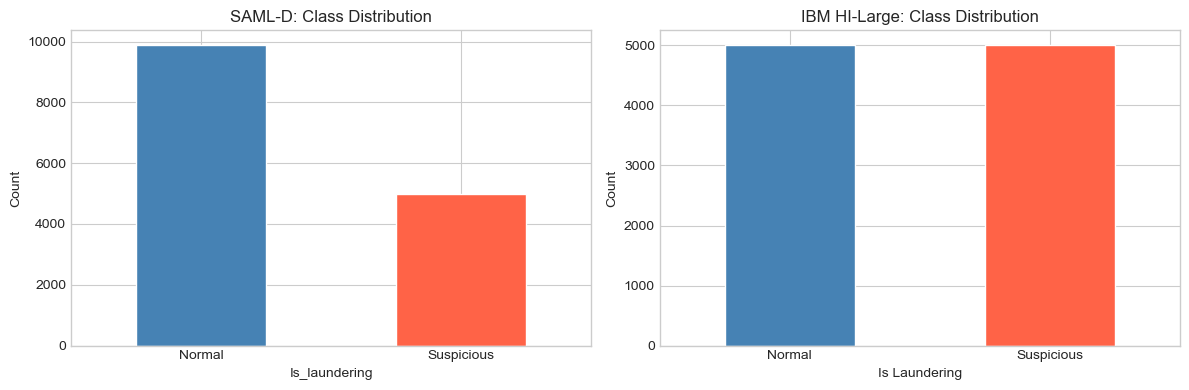

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SAML-D
saml['Is_laundering'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('SAML-D: Class Distribution')
axes[0].set_xticklabels(['Normal', 'Suspicious'], rotation=0)
axes[0].set_ylabel('Count')

# IBM
ibm['Is Laundering'].value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[1].set_title('IBM HI-Large: Class Distribution')
axes[1].set_xticklabels(['Normal', 'Suspicious'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

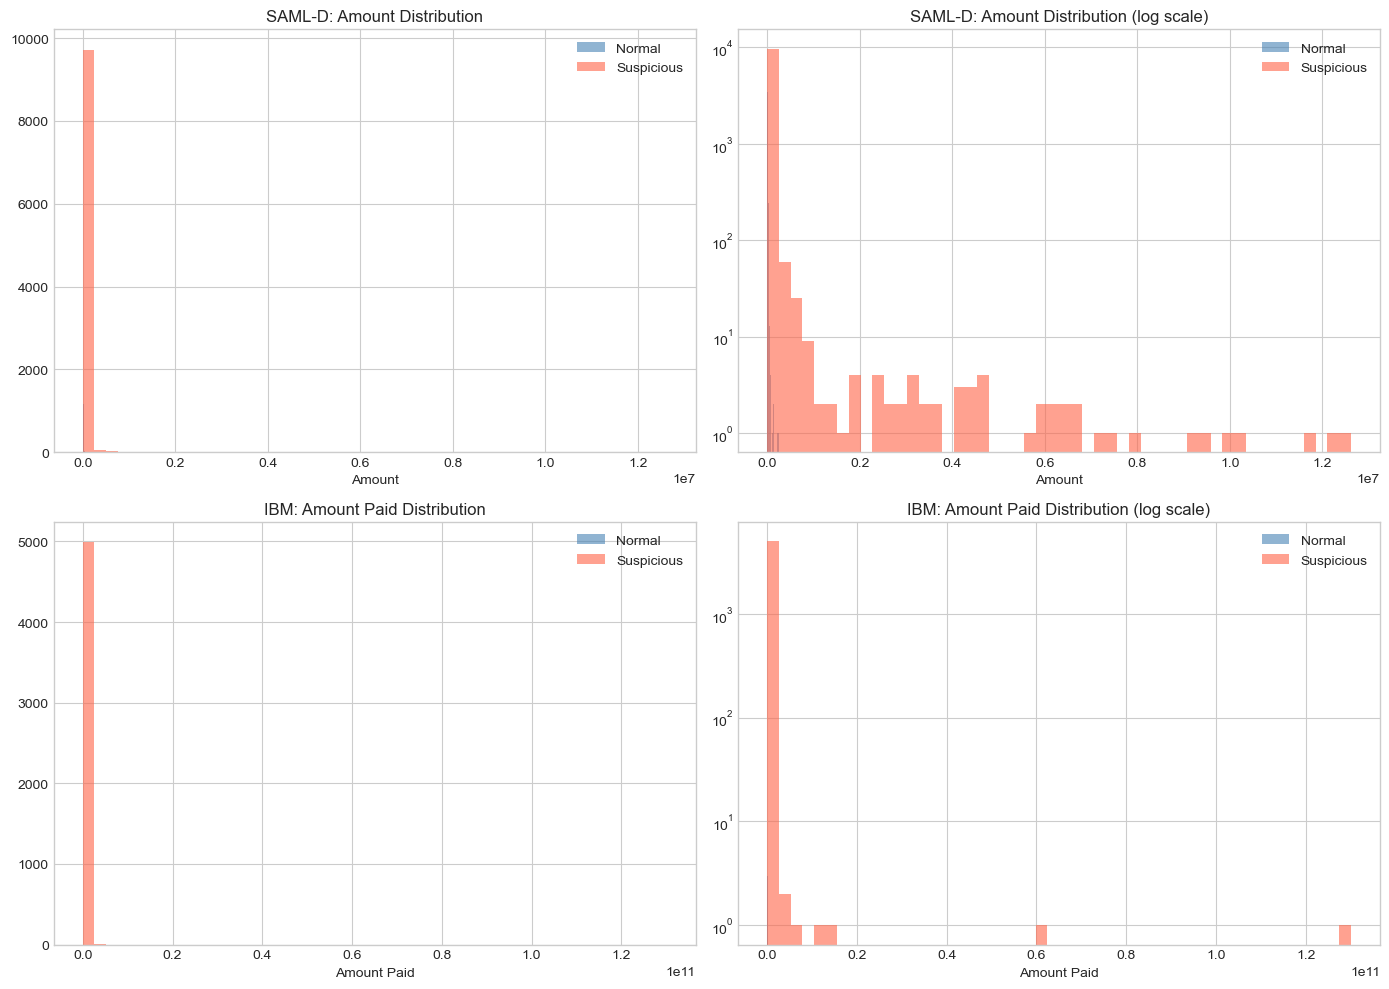

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SAML-D histograms
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Suspicious')]:
    subset = saml[saml['Is_laundering'] == label]['Amount']
    axes[0][0].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[0][0].set_title('SAML-D: Amount Distribution')
axes[0][0].set_xlabel('Amount')
axes[0][0].legend()

# SAML-D log scale
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Suspicious')]:
    subset = saml[saml['Is_laundering'] == label]['Amount']
    axes[0][1].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[0][1].set_yscale('log')
axes[0][1].set_title('SAML-D: Amount Distribution (log scale)')
axes[0][1].set_xlabel('Amount')
axes[0][1].legend()

# IBM histograms
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Suspicious')]:
    subset = ibm[ibm['Is Laundering'] == label]['Amount Paid']
    axes[1][0].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[1][0].set_title('IBM: Amount Paid Distribution')
axes[1][0].set_xlabel('Amount Paid')
axes[1][0].legend()

# IBM log scale
for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Suspicious')]:
    subset = ibm[ibm['Is Laundering'] == label]['Amount Paid']
    axes[1][1].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[1][1].set_yscale('log')
axes[1][1].set_title('IBM: Amount Paid Distribution (log scale)')
axes[1][1].set_xlabel('Amount Paid')
axes[1][1].legend()

plt.tight_layout()
plt.show()

C:\Users\Славена\AppData\Local\Temp\ipykernel_6260\2383292209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=saml, x='Label', y='Amount', ax=axes[0],
C:\Users\Славена\AppData\Local\Temp\ipykernel_6260\2383292209.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ibm, x='Label', y='Amount Paid', ax=axes[1],


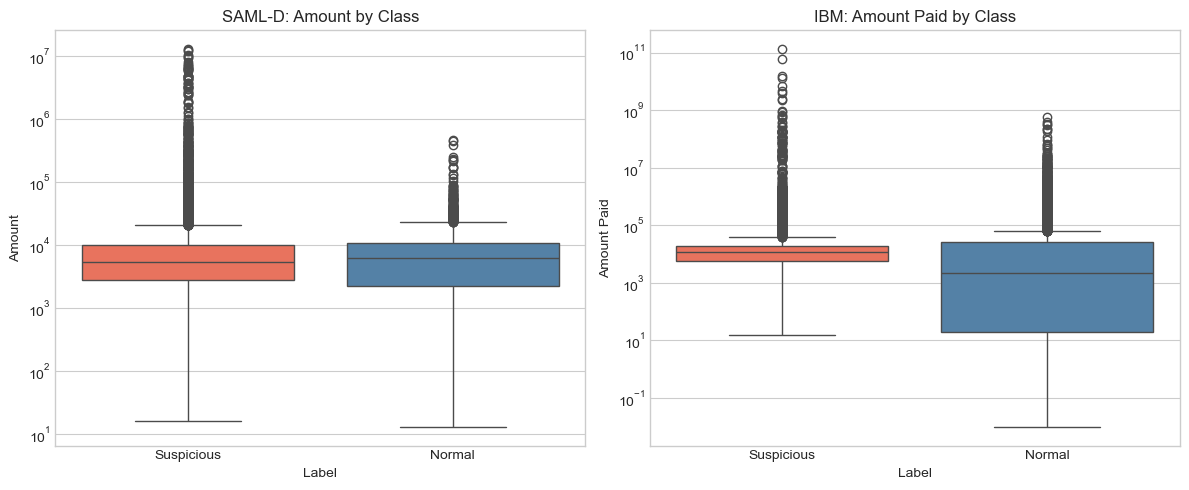

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SAML-D boxplot
saml['Label'] = saml['Is_laundering'].map({0.0: 'Normal', 1.0: 'Suspicious'})
sns.boxplot(data=saml, x='Label', y='Amount', ax=axes[0],
            palette={'Normal': 'steelblue', 'Suspicious': 'tomato'})
axes[0].set_title('SAML-D: Amount by Class')
axes[0].set_yscale('log')

# IBM boxplot
ibm['Label'] = ibm['Is Laundering'].map({0: 'Normal', 1: 'Suspicious'})
sns.boxplot(data=ibm, x='Label', y='Amount Paid', ax=axes[1],
            palette={'Normal': 'steelblue', 'Suspicious': 'tomato'})
axes[1].set_title('IBM: Amount Paid by Class')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

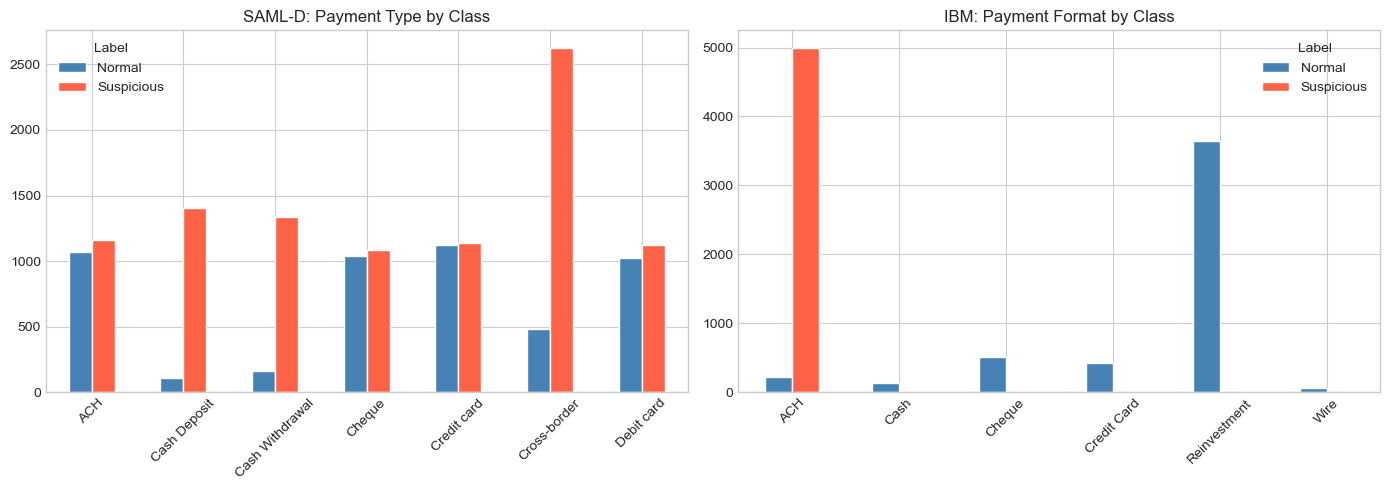

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SAML-D payment type
saml.groupby(['Payment_type', 'Label']).size().unstack().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('SAML-D: Payment Type by Class')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# IBM payment format
ibm.groupby(['Payment Format', 'Label']).size().unstack().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[1].set_title('IBM: Payment Format by Class')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Data Cleaning & Preprocessing

Before applying statistical tests and anomaly detection, we check for missing values,
inspect data types, and prepare the features for analysis.

In [15]:
print("=== SAML-D: Missing Values ===")
print(saml.isnull().sum())
print(f"\nTotal missing: {saml.isnull().sum().sum()}")

print("\n=== IBM: Missing Values ===")
print(ibm.isnull().sum())
print(f"\nTotal missing: {ibm.isnull().sum().sum()}")

=== SAML-D: Missing Values ===
Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
Label                     0
dtype: int64

Total missing: 0

=== IBM: Missing Values ===
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
Label                 0
dtype: int64

Total missing: 0


In [16]:
print("=== SAML-D: Data Types ===")
print(saml.dtypes)

print("\n=== IBM: Data Types ===")
print(ibm.dtypes)

=== SAML-D: Data Types ===
Time                       object
Date                       object
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency           object
Received_currency          object
Sender_bank_location       object
Receiver_bank_location     object
Payment_type               object
Is_laundering               int64
Laundering_type            object
Label                      object
dtype: object

=== IBM: Data Types ===
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
Label                  object
dtype: object


In [19]:
from sklearn.preprocessing import StandardScaler

# ── SAML-D ─────────────────────────────────────────────
scaler = StandardScaler()
saml['Amount_scaled'] = scaler.fit_transform(saml[['Amount']])

# Hour of day от Time колоната
saml['Hour'] = pd.to_datetime(saml['Time'], format='%H:%M:%S').dt.hour

# Currency mismatch flag
saml['Currency_mismatch'] = (saml['Payment_currency'] != saml['Received_currency']).astype(int)

print("SAML-D new columns:")
print(saml[['Amount', 'Amount_scaled', 'Hour', 'Currency_mismatch']].head())

# ── IBM ─────────────────────────────────────────────────
ibm['Amount Paid'] = pd.to_numeric(ibm['Amount Paid'], errors='coerce')
ibm['Amount_scaled'] = scaler.fit_transform(ibm[['Amount Paid']])

# Currency mismatch
ibm['Currency_mismatch'] = (ibm['Payment Currency'] != ibm['Receiving Currency']).astype(int)

print("\nIBM new columns:")
print(ibm[['Amount Paid', 'Amount_scaled', 'Currency_mismatch']].head())

SAML-D new columns:
     Amount  Amount_scaled  Hour  Currency_mismatch
0   6804.32      -0.067220    20                  1
1  18157.71      -0.034019    23                  0
2    175.35      -0.086605    16                  0
3   6329.32      -0.068609    13                  1
4   5064.11      -0.072308    12                  0

IBM new columns:
   Amount Paid  Amount_scaled  Currency_mismatch
0       184.99      -0.017508                  0
1    593129.88      -0.017101                  0
2         1.29      -0.017508                  0
3      2360.16      -0.017507                  0
4       770.35      -0.017508                  0


In [20]:
print("=== SAML-D final columns ===")
print(saml.columns.tolist())
print(f"Shape: {saml.shape}")

print("\n=== IBM final columns ===")
print(ibm.columns.tolist())
print(f"Shape: {ibm.shape}")

=== SAML-D final columns ===
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type', 'Label', 'Amount_scaled', 'Hour', 'Currency_mismatch']
Shape: (14873, 16)

=== IBM final columns ===
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'Label', 'Amount_scaled', 'Currency_mismatch']
Shape: (10000, 14)


## 6. Hypothesis Testing

We test whether suspicious transactions have significantly higher amounts 
compared to normal transactions.

**H₀:** μ_suspicious = μ_normal  
**H₁:** μ_suspicious > μ_normal  
**Significance level:** α = 0.05  
**Test type:** One-tailed (right-tailed)

We first check normality using the Shapiro-Wilk test to determine whether 
to use a parametric (T-test) or non-parametric (Mann-Whitney U) test.

In [21]:
from scipy.stats import shapiro, mannwhitneyu, ttest_ind

# ── SAML-D ─────────────────────────────────────────────
saml_normal_amt = saml[saml['Is_laundering'] == 0]['Amount']
saml_susp_amt   = saml[saml['Is_laundering'] == 1]['Amount']

# Shapiro-Wilk работи до 5000 реда — вземаме извадка
stat_n, p_n = shapiro(saml_normal_amt.sample(min(1000, len(saml_normal_amt)), random_state=42))
stat_s, p_s = shapiro(saml_susp_amt.sample(min(1000, len(saml_susp_amt)), random_state=42))

print("=== SAML-D: Shapiro-Wilk Test ===")
print(f"Normal transactions:     stat={stat_n:.4f}, p={p_n:.6f}")
print(f"Suspicious transactions: stat={stat_s:.4f}, p={p_s:.6f}")
print(f"Normal distribution? Normal={p_n > 0.05}, Suspicious={p_s > 0.05}")

# ── IBM ─────────────────────────────────────────────────
ibm['Amount Paid'] = pd.to_numeric(ibm['Amount Paid'], errors='coerce')
ibm_normal_amt = ibm[ibm['Is Laundering'] == 0]['Amount Paid'].dropna()
ibm_susp_amt   = ibm[ibm['Is Laundering'] == 1]['Amount Paid'].dropna()

stat_n2, p_n2 = shapiro(ibm_normal_amt.sample(min(1000, len(ibm_normal_amt)), random_state=42))
stat_s2, p_s2 = shapiro(ibm_susp_amt.sample(min(1000, len(ibm_susp_amt)), random_state=42))

print("\n=== IBM: Shapiro-Wilk Test ===")
print(f"Normal transactions:     stat={stat_n2:.4f}, p={p_n2:.6f}")
print(f"Suspicious transactions: stat={stat_s2:.4f}, p={p_s2:.6f}")
print(f"Normal distribution? Normal={p_n2 > 0.05}, Suspicious={p_s2 > 0.05}")

=== SAML-D: Shapiro-Wilk Test ===
Normal transactions:     stat=0.2123, p=0.000000
Suspicious transactions: stat=0.0786, p=0.000000
Normal distribution? Normal=False, Suspicious=False

=== IBM: Shapiro-Wilk Test ===
Normal transactions:     stat=0.0327, p=0.000000
Suspicious transactions: stat=0.0155, p=0.000000
Normal distribution? Normal=False, Suspicious=False


In [22]:
# ── SAML-D Mann-Whitney U (one-tailed) ─────────────────
stat_mw, p_mw = mannwhitneyu(saml_susp_amt, saml_normal_amt, alternative='greater')

print("=== SAML-D: Mann-Whitney U Test ===")
print(f"Statistic: {stat_mw:.2f}")
print(f"P-value:   {p_mw:.6f}")
print(f"Result:    {'Reject H₀ ✓' if p_mw < 0.05 else 'Fail to reject H₀'}")

# ── IBM Mann-Whitney U (one-tailed) ─────────────────────
stat_mw2, p_mw2 = mannwhitneyu(ibm_susp_amt, ibm_normal_amt, alternative='greater')

print("\n=== IBM: Mann-Whitney U Test ===")
print(f"Statistic: {stat_mw2:.2f}")
print(f"P-value:   {p_mw2:.6f}")
print(f"Result:    {'Reject H₀ ✓' if p_mw2 < 0.05 else 'Fail to reject H₀'}")

=== SAML-D: Mann-Whitney U Test ===
Statistic: 23718162.00
P-value:   0.999952
Result:    Fail to reject H₀

=== IBM: Mann-Whitney U Test ===
Statistic: 17004959.50
P-value:   0.000000
Result:    Reject H₀ ✓


In [23]:
import numpy as np

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - margin, mean + margin

from scipy import stats

print("=== SAML-D: 95% Confidence Intervals for Amount ===")
mean_n, lo_n, hi_n = confidence_interval(saml_normal_amt)
mean_s, lo_s, hi_s = confidence_interval(saml_susp_amt)
print(f"Normal:     mean={mean_n:.2f}, CI=[{lo_n:.2f}, {hi_n:.2f}]")
print(f"Suspicious: mean={mean_s:.2f}, CI=[{lo_s:.2f}, {hi_s:.2f}]")

print("\n=== IBM: 95% Confidence Intervals for Amount Paid ===")
mean_n2, lo_n2, hi_n2 = confidence_interval(ibm_normal_amt)
mean_s2, lo_s2, hi_s2 = confidence_interval(ibm_susp_amt)
print(f"Normal:     mean={mean_n2:.2f}, CI=[{lo_n2:.2f}, {hi_n2:.2f}]")
print(f"Suspicious: mean={mean_s2:.2f}, CI=[{lo_s2:.2f}, {hi_s2:.2f}]")

=== SAML-D: 95% Confidence Intervals for Amount ===
Normal:     mean=8472.14, CI=[8044.48, 8899.79]
Suspicious: mean=40587.67, CI=[32318.18, 48857.15]

=== IBM: 95% Confidence Intervals for Amount Paid ===
Normal:     mean=826871.31, CI=[462887.03, 1190855.59]
Suspicious: mean=50114799.34, CI=[-6921715.21, 107151313.90]


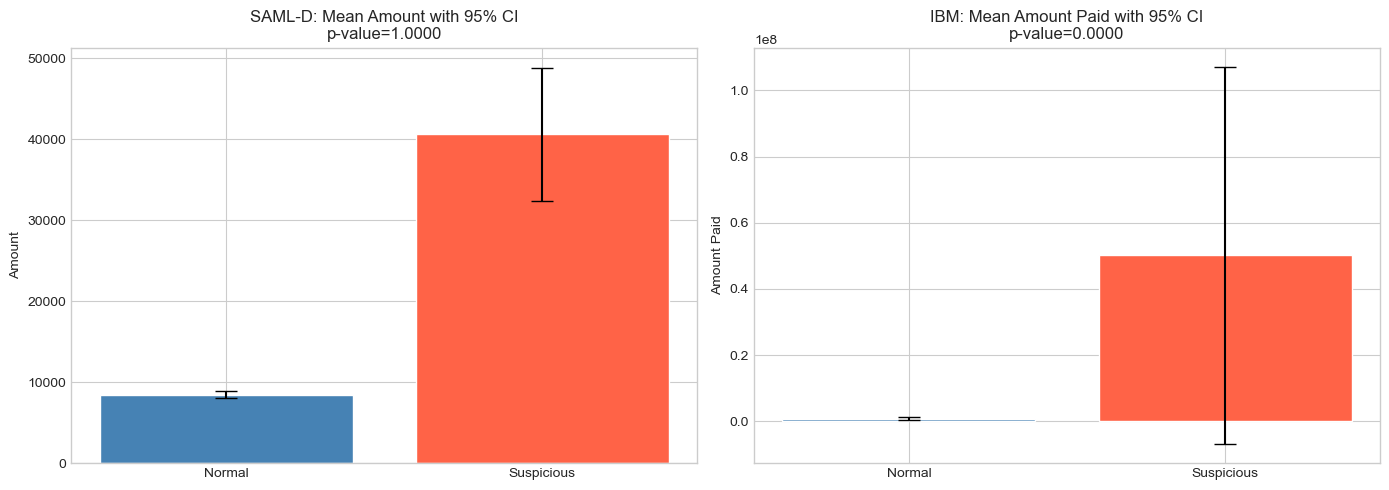

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SAML-D
axes[0].bar(['Normal', 'Suspicious'], [mean_n, mean_s],
            yerr=[[mean_n-lo_n, mean_s-lo_s], [hi_n-mean_n, hi_s-mean_s]],
            color=['steelblue', 'tomato'], capsize=8, edgecolor='white')
axes[0].set_title(f'SAML-D: Mean Amount with 95% CI\np-value={p_mw:.4f}')
axes[0].set_ylabel('Amount')

# IBM
axes[1].bar(['Normal', 'Suspicious'], [mean_n2, mean_s2],
            yerr=[[mean_n2-lo_n2, mean_s2-lo_s2], [hi_n2-mean_n2, hi_s2-mean_s2]],
            color=['steelblue', 'tomato'], capsize=8, edgecolor='white')
axes[1].set_title(f'IBM: Mean Amount Paid with 95% CI\np-value={p_mw2:.4f}')
axes[1].set_ylabel('Amount Paid')

plt.tight_layout()
plt.show()

### Hypothesis Testing Conclusion

Based on the Mann-Whitney U one-tailed test (H₁: suspicious > normal):

| Dataset | Statistic | P-value | Result |
|---------|-----------|---------|--------|
| SAML-D | 23,718,162 | 0.9999 | Fail to reject H₀ |
| IBM HI-Large | 17,004,959 | < 0.0001 | Reject H₀ ✓ |

**SAML-D:** We fail to reject H₀. Suspicious transactions do NOT have 
significantly higher amounts. This suggests that in SAML-D, money laundering 
is spread across many small transactions (e.g. Structuring, Smurfing) — 
criminals deliberately keep amounts low to avoid detection.

**IBM HI-Large:** We reject H₀. Suspicious transactions have significantly 
higher amounts, confirming H₁.

This contrast between datasets highlights an important limitation of 
amount-based detection: sophisticated laundering schemes actively avoid 
large transactions. This motivates the use of multi-feature anomaly detection 
methods in the next section.